# 1. Gradient Boost ML Algorithm
# 2. XG Boost ML Algorithm

## 1. Import Necessary Libraries

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from ydata_profiling import ProfileReport
%matplotlib inline

from sklearn import datasets
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler 
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

## 2. Load and Explore data

In [5]:
cancer = datasets.load_breast_cancer()
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['Target'] = cancer.target
print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [19]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [7]:
print(df.duplicated().sum())

0


In [8]:
print((df == 0).sum())

mean radius                  0
mean texture                 0
mean perimeter               0
mean area                    0
mean smoothness              0
mean compactness             0
mean concavity              13
mean concave points         13
mean symmetry                0
mean fractal dimension       0
radius error                 0
texture error                0
perimeter error              0
area error                   0
smoothness error             0
compactness error            0
concavity error             13
concave points error        13
symmetry error               0
fractal dimension error      0
worst radius                 0
worst texture                0
worst perimeter              0
worst area                   0
worst smoothness             0
worst compactness            0
worst concavity             13
worst concave points        13
worst symmetry               0
worst fractal dimension      0
Target                     212
dtype: int64


In [9]:
print("Columns with exactly 2 unique values:")
for col in df.columns:
    unique_values = df[col].dropna().unique()  
    if len(unique_values) == 2:
        print(f"Column '{col}':")
        print(df[col].value_counts())

Columns with exactly 2 unique values:
Column 'Target':
Target
1    357
0    212
Name: count, dtype: int64


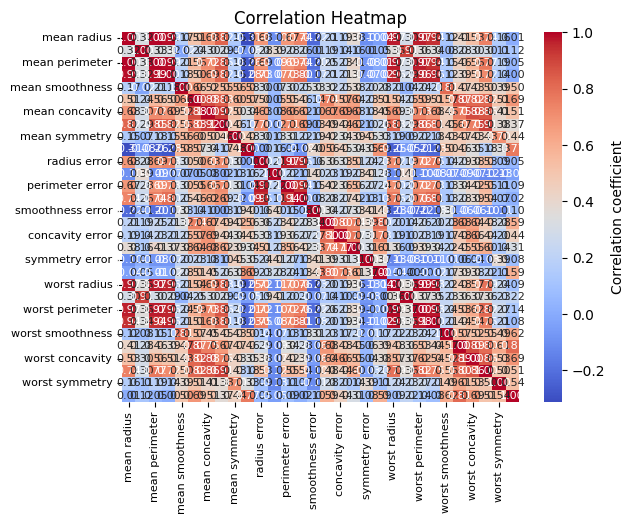

In [10]:
# correlation matrix 
numeric_data = df.select_dtypes(include=['float64', 'int64'])

sns.heatmap(numeric_data.corr(), annot=True, 
             cmap="coolwarm", fmt=".2f", annot_kws={"size": 8}, 
             cbar_kws={'label': 'Correlation coefficient'})
plt.title("Correlation Heatmap")
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.show()

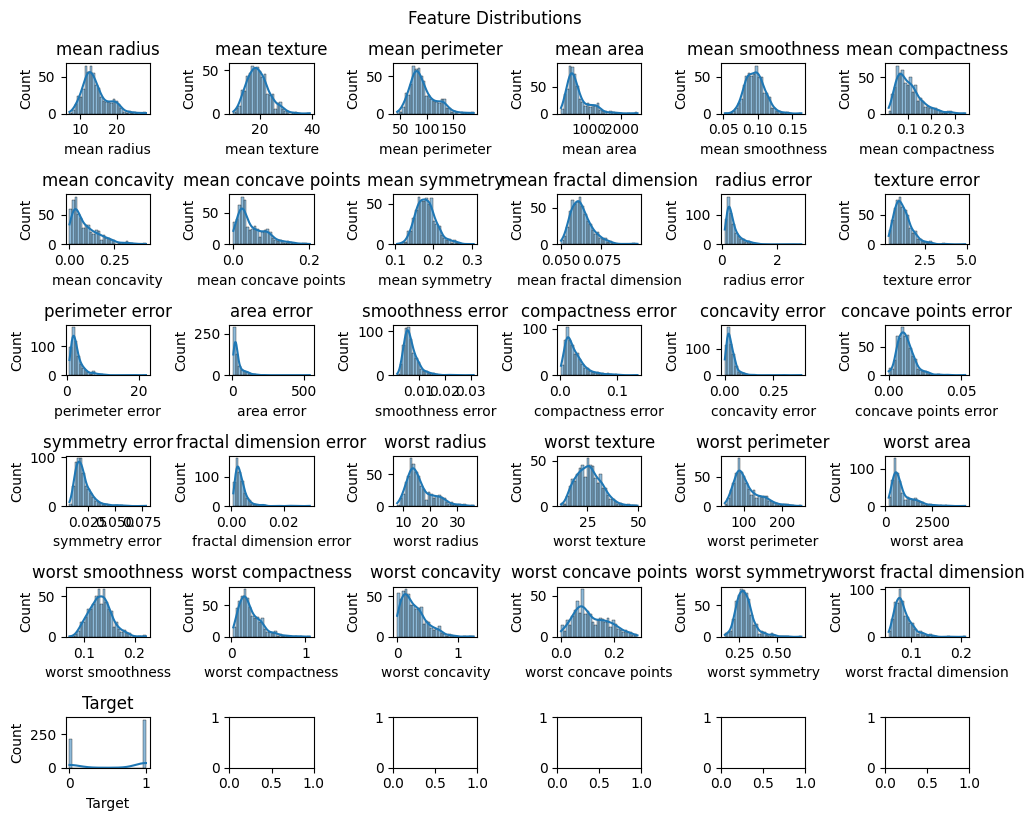

In [11]:
# Feature Distributions: 
numeric_columns = df.select_dtypes(include=['number']).columns

fig, axes = plt.subplots(6, 6, figsize=(10, 8))
axes = axes.flatten()

for i, column in enumerate(numeric_columns):
    sns.histplot(data=df, x=column, kde=True, bins=30, ax=axes[i])  
    axes[i].set_title(f'{column}')  
plt.tight_layout()
plt.suptitle("Feature Distributions", y=1.02)  
plt.show()

In [12]:
# Skewness and kurtosis help evaluate the distribution of numerical features
# Skewness close to 0 suggests a symmetric distribution, 
# positive skew (>0) indicates a right tail,  
# negative skew (<0) indicates a left tail.

# Kurtosis values around 3 indicate a normal distribution. 
# Values > 3 suggest heavy tails (outliers), 
# while < 3 suggests light tails.

print("Skewness for numerical columns:")
print(df.select_dtypes(include=['number']).skew())

print("Kurtosis for numerical columns:")
print(df.select_dtypes(include=['number']).kurt())

Skewness for numerical columns:
mean radius                0.942380
mean texture               0.650450
mean perimeter             0.990650
mean area                  1.645732
mean smoothness            0.456324
mean compactness           1.190123
mean concavity             1.401180
mean concave points        1.171180
mean symmetry              0.725609
mean fractal dimension     1.304489
radius error               3.088612
texture error              1.646444
perimeter error            3.443615
area error                 5.447186
smoothness error           2.314450
compactness error          1.902221
concavity error            5.110463
concave points error       1.444678
symmetry error             2.195133
fractal dimension error    3.923969
worst radius               1.103115
worst texture              0.498321
worst perimeter            1.128164
worst area                 1.859373
worst smoothness           0.415426
worst compactness          1.473555
worst concavity            1.150

Number of outliers in each column: 
mean radius                14
mean texture                7
mean perimeter             13
mean area                  25
mean smoothness             6
mean compactness           16
mean concavity             18
mean concave points        10
mean symmetry              15
mean fractal dimension     15
radius error               38
texture error              20
perimeter error            38
area error                 65
smoothness error           30
compactness error          28
concavity error            22
concave points error       19
symmetry error             27
fractal dimension error    28
worst radius               17
worst texture               5
worst perimeter            15
worst area                 35
worst smoothness            7
worst compactness          16
worst concavity            12
worst concave points        0
worst symmetry             23
worst fractal dimension    24
dtype: int64


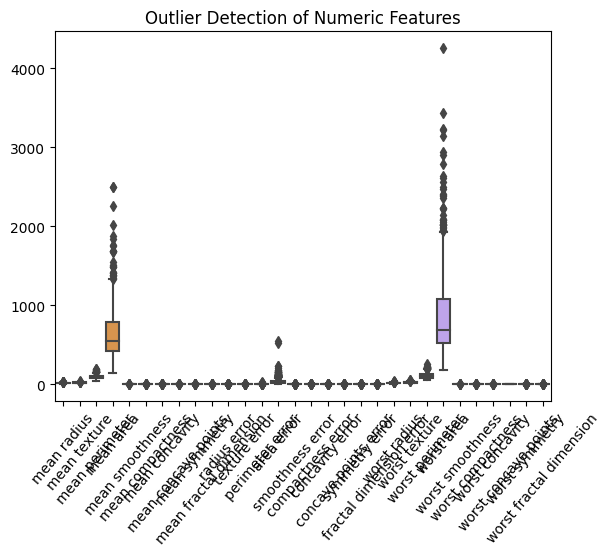

In [13]:
# Outlier Detection 
numeric_df = df.select_dtypes(include=['float64', 'int64'])
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1
outliers = ((numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))).sum()
print(f"Number of outliers in each column: \n{outliers}")

sns.boxplot(data=numeric_df)
plt.title("Outlier Detection of Numeric Features")
plt.xticks(rotation=50)
plt.show()

Target Class Distribution:
Target
1    357
0    212
Name: count, dtype: int64

Target Class Distribution (Percentage):
Target
1    0.627417
0    0.372583
Name: proportion, dtype: float64

Missing Values: 0
Unique Values: [0 1]


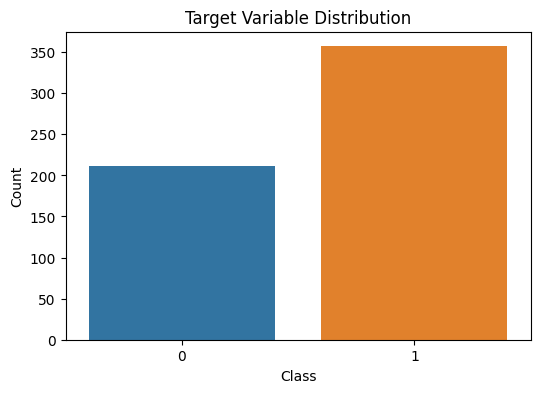

In [14]:
# EDA the target 
print("Target Class Distribution:")
print(df['Target'].value_counts())
print("\nTarget Class Distribution (Percentage):")
print(df['Target'].value_counts(normalize=True))
print(f"\nMissing Values: {df['Target'].isnull().sum()}")
print(f"Unique Values: {df['Target'].unique()}")

plt.figure(figsize=(6, 4))
sns.countplot(x='Target', data=df)
plt.title('Target Variable Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [15]:
# Group columns by data types
for dtype in df.dtypes.unique():
    print(f"\n{dtype} columns:")
    print(df.select_dtypes(include=[dtype]).columns.tolist())


float64 columns:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']

int32 columns:
['Target']


## 3. Splitting Data into Training and Test Sets

In [17]:
x = df.drop(columns=['Target'])  
y = df['Target']                 

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"x_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"x_test: {x_test.shape}, y_test: {y_test.shape}")

x_train: (455, 30), y_train: (455,)
x_test: (114, 30), y_test: (114,)


## 4. Data Preprocessing

In [20]:
# Handle Outliers by using IQR
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
numerical_columns = x_train.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_columns:
    cap_outliers(x_train, col)
    cap_outliers(x_test, col)

print(f"Preprocessed Training set:\n{x_train.head()}")

Preprocessed Training set:
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
68         9.029         17.33           58.79     250.50          0.10660   
181       21.090         26.57          142.70    1288.55          0.11410   
63         9.173         13.86           59.20     260.90          0.07721   
248       10.650         25.22           68.01     347.00          0.09657   
60        10.170         14.88           64.55     311.90          0.11340   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
68           0.141300        0.286895              0.04375       0.211100   
181          0.233915        0.248700              0.14960       0.239500   
63           0.087510        0.059880              0.02180       0.234100   
248          0.072340        0.023790              0.01615       0.189700   
60           0.080610        0.010840              0.01290       0.246725   

     mean fractal dimension  ...  worst r

In [21]:
scaler_robust = RobustScaler()
numerical_columns = x_train.select_dtypes(include=['float64', 'int64']).columns
x_train[numerical_columns] = scaler_robust.fit_transform(x_train[numerical_columns])
x_test[numerical_columns] = scaler_robust.transform(x_test[numerical_columns])

print(f"Preprocessed Training set:\n{x_train.head()}")

Preprocessed Training set:
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
68     -1.058488     -0.249307       -0.949040  -0.867262         0.639786   
181     1.930607      1.457064        1.979756   2.121653         1.040320   
63     -1.022800     -0.890120       -0.934729  -0.837316        -0.929773   
248    -0.656753      1.207756       -0.627225  -0.589404         0.104139   
60     -0.775713     -0.701754       -0.747993  -0.690469         1.002937   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
68           0.735711        2.187276             0.193073       0.939617   
181          2.089534        1.816558             2.169545       1.776141   
63          -0.050577       -0.016112            -0.216786       1.617084   
248         -0.272329       -0.366398            -0.322286       0.309278   
60          -0.151440       -0.492090            -0.382971       1.988954   

     mean fractal dimension  ...  worst r

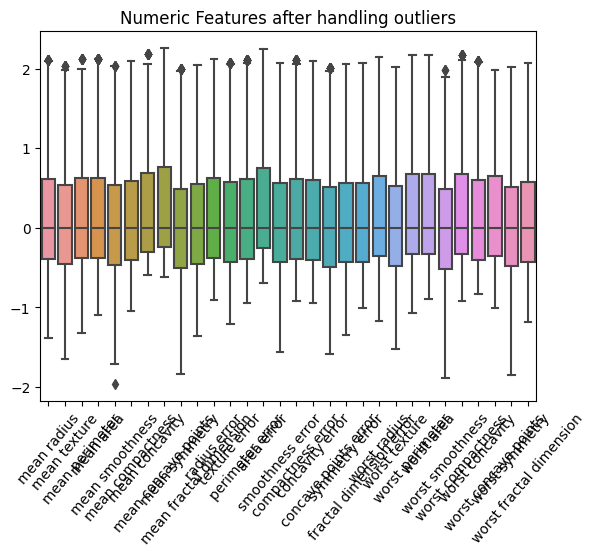

In [22]:
sns.boxplot(data=x_train[numerical_columns])
plt.title("Numeric Features after handling outliers")
plt.xticks(rotation=50)
plt.show()

## 5. Model Fitting, Test, Evaluation 

# Building and Training the GradientBoostingClassifier

In [23]:
model = GradientBoostingClassifier(n_estimators=100, learning_rate=1.0, max_depth=1, random_state=42)
model.fit(x_train, y_train)
accuracy = model.score(x_test, y_test)
print(f"Accuracy: Model GradientBoostingClassifier testing dataset: {accuracy:.2f}")

Accuracy: Model GradientBoostingClassifier testing dataset: 0.97


In [24]:
model = GradientBoostingClassifier(n_estimators=100, learning_rate=1.0, max_depth=1, random_state=42)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix: Model GradientBoostingClassifier:")
print(cm)

print(f"Classification Report: Model GradientBoostingClassifier: ")
print(classification_report(y_test, y_pred, zero_division=0))

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: Model GradientBoostingClassifier: {accuracy:.4f}")

cv_scores = cross_val_score(model, x_train, y_train, cv=5)
print(f"Cross-validation scores: Model GradientBoostingClassifier:{cv_scores}")
print(f"Average cross-validation score: Model GradientBoostingClassifier: {cv_scores.mean():.2f}")


Confusion Matrix: Model GradientBoostingClassifier:
[[41  2]
 [ 1 70]]
Classification Report: Model GradientBoostingClassifier: 
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Accuracy: Model GradientBoostingClassifier: 0.9737
Cross-validation scores: Model GradientBoostingClassifier:[0.97802198 0.95604396 0.97802198 0.98901099 0.95604396]
Average cross-validation score: Model GradientBoostingClassifier: 0.97


# Building and Training the XGBoost Classifier

In [25]:
model = XGBClassifier(
    objective='binary:logistic',  # For binary classification
    n_estimators=100,             # Number of boosting rounds
    max_depth=3,                  # Maximum tree depth
    learning_rate=0.1,            # Step size shrinkage
    random_state=42
)
model.fit(x_train, y_train)
accuracy = model.score(x_test, y_test)
print(f"Accuracy: Model XGBClassifier testing dataset: {accuracy:.2f}")

Accuracy: Model XGBClassifier testing dataset: 0.96


In [26]:
model = XGBClassifier(
    objective='binary:logistic',  # For binary classification
    n_estimators=100,             # Number of boosting rounds
    max_depth=3,                  # Maximum tree depth
    learning_rate=0.1,            # Step size shrinkage
    random_state=42
)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix: Model XGBClassifier:")
print(cm)

print(f"Classification Report: Model XGBClassifier: ")
print(classification_report(y_test, y_pred, zero_division=0))

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: Model XGBClassifier: {accuracy:.4f}")

cv_scores = cross_val_score(model, x_train, y_train, cv=5)
print(f"Cross-validation scores: Model XGBClassifier:{cv_scores}")
print(f"Average cross-validation score: Model XGBClassifier: {cv_scores.mean():.2f}")

Confusion Matrix: Model XGBClassifier:
[[40  3]
 [ 2 69]]
Classification Report: Model XGBClassifier: 
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Accuracy: Model XGBClassifier: 0.9561
Cross-validation scores: Model XGBClassifier:[0.96703297 0.95604396 0.98901099 0.96703297 0.95604396]
Average cross-validation score: Model XGBClassifier: 0.97
